In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [68]:
train_data = pd.read_csv("../data/train.csv")

In [69]:
churn_data = train_data.copy()
churn_data["churn_flag"] = churn_data["Churn"].map({"No": 0, "Yes": 1})

Churn Distribution

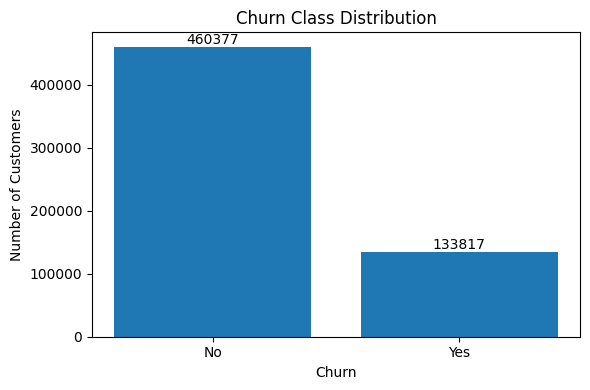

In [ ]:
churn_counts = churn_data["Churn"].value_counts()

plt.figure(figsize=(6, 4))
bars = plt.bar(churn_counts.index, churn_counts.values)

plt.title("Churn Class Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig("../screenshots/churn_distribution.png", dpi=150)
plt.show()

Churn rate by contract type

In [71]:
contract_summary = churn_data.groupby("Contract")["churn_flag"].agg(["count", "mean"])
contract_summary["churn_rate_percent"] = contract_summary["mean"] * 100
contract_summary = contract_summary.sort_values("churn_rate_percent", ascending=False)

contract_summary

,count,mean,churn_rate_percent
Contract,,,
Month-to-month,298918,0.420543,42.054343
One year,108333,0.057628,5.762787
Two year,186943,0.009982,0.998165


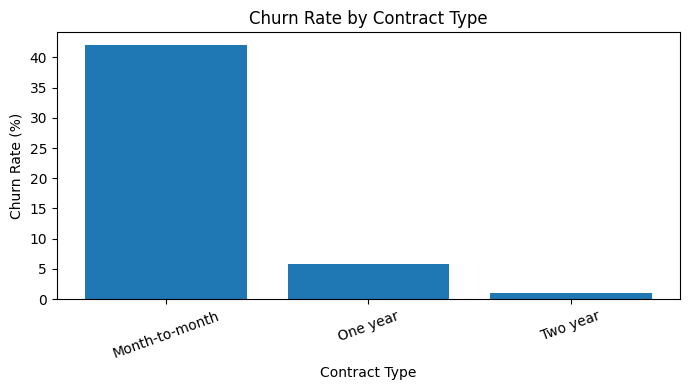

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(contract_summary.index, contract_summary["churn_rate_percent"])

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../screenshots/churn_rate_by_contract.png", dpi=150)
plt.show()

Churn rate by payment method

In [73]:
payment_summary = churn_data.groupby("PaymentMethod")["churn_flag"].agg(["count", "mean"])
payment_summary["churn_rate_percent"] = payment_summary["mean"] * 100
payment_summary = payment_summary.sort_values("churn_rate_percent", ascending=False)

payment_summary

,count,mean,churn_rate_percent
PaymentMethod,,,
Electronic check,215372,0.489052,48.905150
Mailed check,123757,0.079697,7.969650
Bank transfer (automatic),121360,0.077093,7.709295
Credit card (automatic),133705,0.069332,6.933174


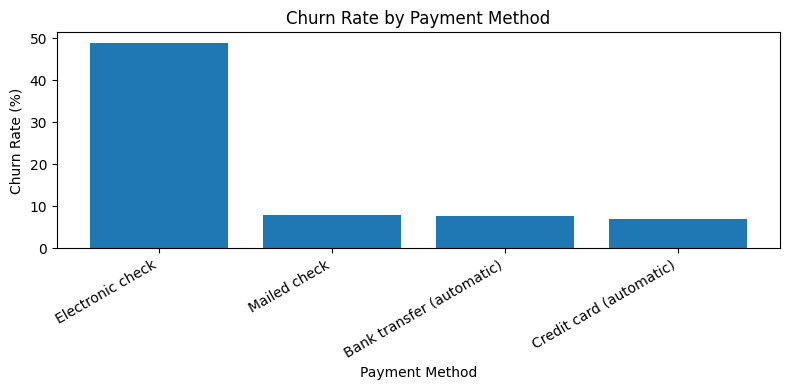

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(payment_summary.index, payment_summary["churn_rate_percent"])

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../screenshots/churn_rate_by_payment_method.png", dpi=150)
plt.show()

Churn rate by internet service

In [75]:
internet_summary = churn_data.groupby("InternetService")["churn_flag"].agg(["count", "mean"])
internet_summary["churn_rate_percent"] = internet_summary["mean"] * 100
internet_summary = internet_summary.sort_values("churn_rate_percent", ascending=False)

internet_summary

,count,mean,churn_rate_percent
InternetService,,,
Fiber optic,272386,0.415366,41.536643
DSL,181081,0.103064,10.306437
No,140727,0.014311,1.431140


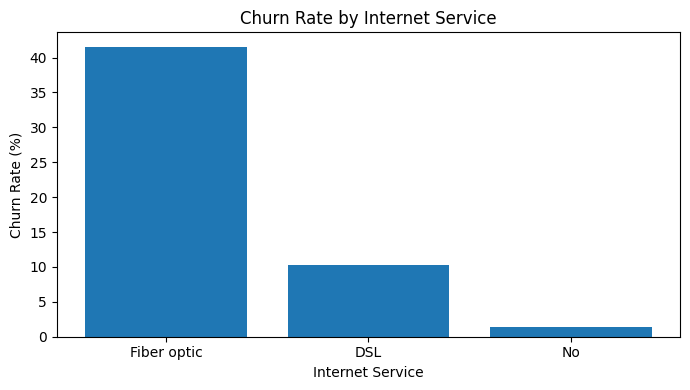

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(internet_summary.index, internet_summary["churn_rate_percent"])

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.savefig("../screenshots/churn_rate_by_internet_service.png", dpi=150)
plt.show()

Churn rate by online security

In [77]:
security_summary = churn_data.groupby("OnlineSecurity")["churn_flag"].agg(["count", "mean"])
security_summary["churn_rate_percent"] = security_summary["mean"] * 100
security_summary = security_summary.sort_values("churn_rate_percent", ascending=False)

security_summary

,count,mean,churn_rate_percent
OnlineSecurity,,,
No,289474,0.406133,40.613319
Yes,163993,0.086821,8.682078
No internet service,140727,0.014311,1.431140


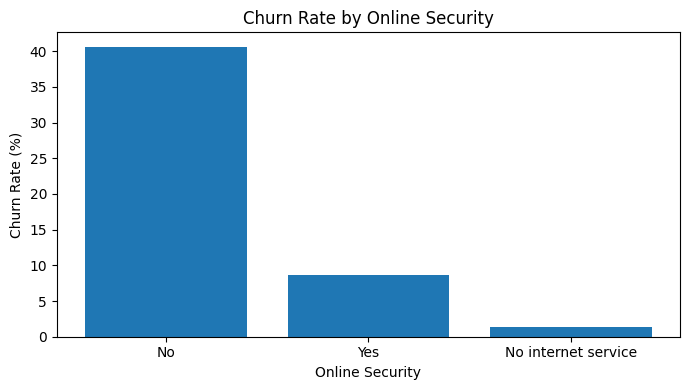

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(security_summary.index, security_summary["churn_rate_percent"])

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.savefig("../screenshots/churn_rate_by_online_security.png", dpi=150)
plt.show()

Churn rate by tech support

In [79]:
support_summary = churn_data.groupby("TechSupport")["churn_flag"].agg(["count", "mean"])
support_summary["churn_rate_percent"] = support_summary["mean"] * 100
support_summary = support_summary.sort_values("churn_rate_percent", ascending=False)

support_summary

,count,mean,churn_rate_percent
TechSupport,,,
No,288571,0.401620,40.162040
Yes,164896,0.096467,9.646686
No internet service,140727,0.014311,1.431140


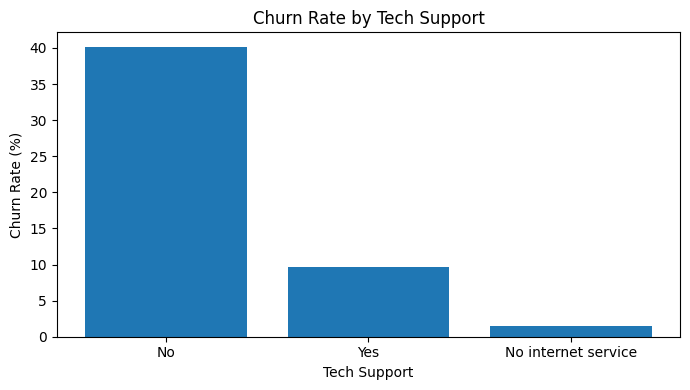

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(support_summary.index, support_summary["churn_rate_percent"])

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.savefig("../screenshots/churn_rate_by_tech_support.png", dpi=150)
plt.show()

Tenure by churn

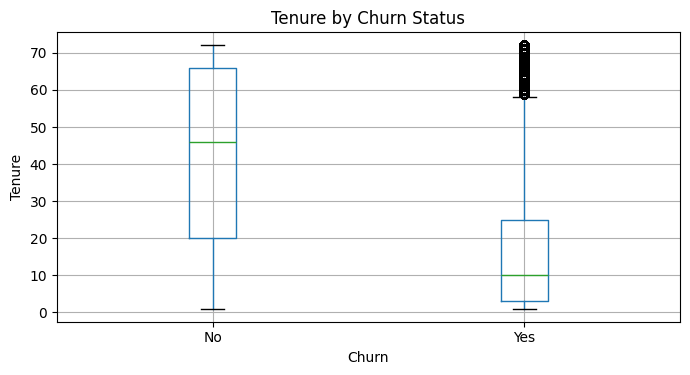

In [81]:
ax = churn_data.boxplot(
    column="tenure",
    by="Churn",
    figsize=(7, 4)
)

ax.set_title("Tenure by Churn Status")
ax.set_xlabel("Churn")
ax.set_ylabel("Tenure")

plt.suptitle("")
plt.tight_layout()

plt.savefig(
    "../screenshots/07_tenure_by_churn.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

Monthly charges by churn

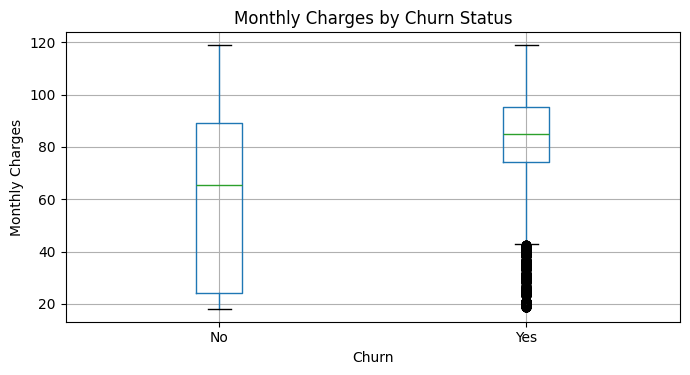

In [82]:
ax = churn_data.boxplot(
    column="MonthlyCharges",
    by="Churn",
    figsize=(7, 4)
)

ax.set_title("Monthly Charges by Churn Status")
ax.set_xlabel("Churn")
ax.set_ylabel("Monthly Charges")

plt.suptitle("")
plt.tight_layout()

plt.savefig(
    "../screenshots/08_monthly_charges_by_churn.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

Numeric correlation with churn

In [83]:
numeric_columns = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "churn_flag"]

correlation_with_churn = churn_data[numeric_columns].corr()["churn_flag"].sort_values(ascending=False)

correlation_with_churn

churn_flag        1.000000
MonthlyCharges    0.272997
SeniorCitizen     0.236362
TotalCharges     -0.218365
tenure           -0.418453
Name: churn_flag, dtype: float64

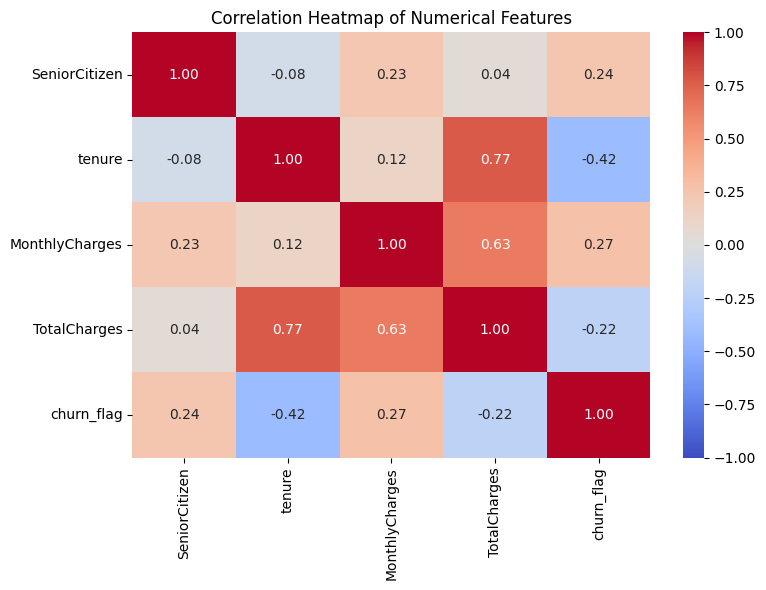

In [ ]:

numeric_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "churn_flag"
]

correlation_matrix = churn_data[numeric_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()

plt.savefig(
    "../screenshots/numeric_correlation_heatmap.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [85]:
# Churn flag for percentage calculations
churn_data["churn_flag"] = (
    churn_data["Churn"]
    .map({"No": 0, "Yes": 1})
)

# Churn rate by contract and internet service
contract_internet_churn = churn_data.pivot_table(
    values="churn_flag",
    index="Contract",
    columns="InternetService",
    aggfunc="mean"
) * 100

display(contract_internet_churn.round(2))

InternetService,DSL,Fiber optic,No
Contract,,,
Month-to-month,22.57,55.01,5.50
One year,2.20,13.27,1.09
Two year,0.40,3.54,0.21


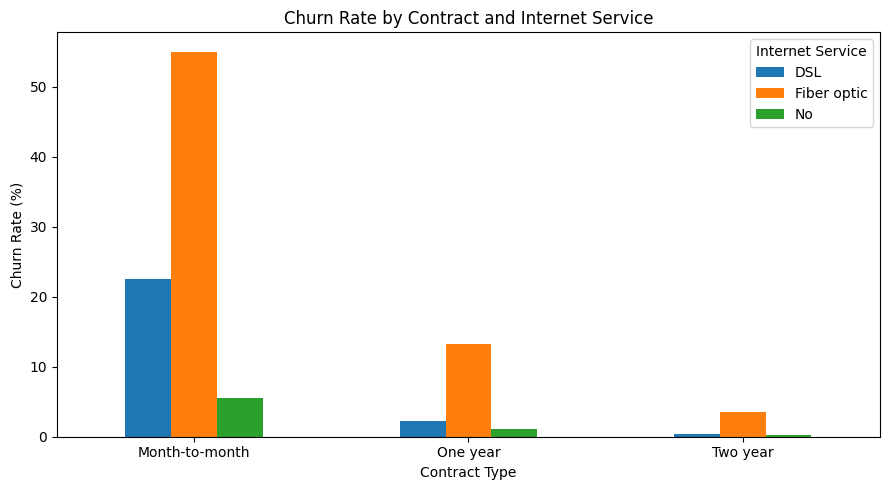

In [ ]:
ax = contract_internet_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title("Churn Rate by Contract and Internet Service")
ax.set_xlabel("Contract Type")
ax.set_ylabel("Churn Rate (%)")
ax.legend(title="Internet Service")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "../screenshots/contract_internet_churn.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()